In [1]:
"""OpenStreetMap → Sionna RT → DeepMIMO: No-Blender Urban Pipeline."""

'OpenStreetMap → Sionna RT → DeepMIMO: No-Blender Urban Pipeline.'

# OpenStreetMap → Sionna RT → DeepMIMO: No-Blender Urban Pipeline

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepMIMO/DeepMIMO/blob/main/docs/applications/4_osm_pipeline.py)
&nbsp;
[![GitHub](https://img.shields.io/badge/Open_on-GitHub-181717?logo=github&style=for-the-badge)](https://github.com/DeepMIMO/DeepMIMO/blob/main/docs/applications/4_osm_pipeline.py)

---

**What this notebook covers:**
1. Define a GPS bounding box around any urban area
2. Download building footprints from **OpenStreetMap** — no Blender required
3. Visualize the scene as a 2D footprint map and in Sionna RT's 3D renderer
4. Run **Sionna RT 2.0** ray tracing on that scene
5. Export and convert the results to a **DeepMIMO** dataset
6. Visualize the reconstructed DeepMIMO scene and channel data

**Why no Blender?**
The traditional pipeline uses Blender + the blosm addon to convert OSM data
into a Mitsuba XML scene.  This notebook skips Blender entirely:
`deepmimo.pipelines.osm_to_mitsuba.generate_scene` queries the Overpass API
directly, extrudes building polygons with NumPy, and writes a valid Mitsuba
scene file that Sionna RT can load immediately.

**Requirements:**
```bash
pip install 'deepmimo[sionna]'
```

---

In [2]:
%pip install 'deepmimo[sionna]'  # uncomment if not installed

/home/joao/DeepMIMO/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


## Imports

In [3]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sionna.rt as sionna_rt
from sionna.rt import Camera, PathSolver, PlanarArray, Receiver, Transmitter

import deepmimo as dm
from deepmimo.exporters.sionna_exporter import sionna_exporter
from deepmimo.pipelines.osm_to_mitsuba import generate_scene
from deepmimo.pipelines.txrx_placement import gen_plane_grid
from deepmimo.pipelines.utils.geo_utils import convert_GpsBBox2CartesianBBox
from deepmimo.pipelines.utils.pipeline_utils import get_origin_coords

## Configuration

Pick any GPS bounding box.  A block of ~300-600 m on a side works well -
large enough to capture reflections, small enough to run quickly.

The example below covers part of **Munich city centre**, Germany.
To use a different location, replace the `BBOX` coordinates with any
GPS bounding box of your choice.

In [4]:
# GPS bounding box — ~400 m x ~400 m block in Munich city centre
BBOX = {
    "minlat": 48.1355,
    "minlon": 11.5735,
    "maxlat": 48.1395,
    "maxlon": 11.5795,
}

CARRIER_FREQ = 3.5e9  # 3.5 GHz

# Sionna RT ray-tracing settings
MAX_DEPTH = 2
N_SAMPLES = 1_000_000

# Transmitter: centre of the area at 25 m height
# (0, 0) is the local coordinate origin = centre of the GPS bbox
TX_POS = np.array([[0.0, 0.0, 25.0]])

# UE grid settings
UE_HEIGHT = 1.5  # metres above ground
GRID_SPACING = 30.0  # metres between UE positions

## Step 1 — Generate the Mitsuba Scene from OSM

`generate_scene` queries the Overpass API for building footprints within the
GPS bounding box, extrudes each polygon into a 3D PLY mesh, creates a flat
ground plane, and writes a `scene.xml` that Sionna RT can load directly.

An `osm_gps_origin.txt` file records the local coordinate origin (centre of
the bbox) so that GPS coordinates can be recovered later.

In [5]:
# Use a persistent folder so the Overpass download is cached between runs.
# Change WORK_DIR to any writable path on your system.
WORK_DIR = Path.home() / ".cache" / "deepmimo" / "osm_pipeline_munich"
WORK_DIR.mkdir(parents=True, exist_ok=True)
scene_folder = str(WORK_DIR)

osm_scene_folder = generate_scene(
    minlat=BBOX["minlat"],
    minlon=BBOX["minlon"],
    maxlat=BBOX["maxlat"],
    maxlon=BBOX["maxlon"],
    scene_folder=str(WORK_DIR / "osm_scene"),
    verbose=True,
)

print(f"\nScene folder : {osm_scene_folder}")
n_buildings = sum(1 for f in Path(osm_scene_folder, "meshes").glob("building_*.ply"))
print(f"Buildings written: {n_buildings}")

Scene already exists at /home/joao/.cache/deepmimo/osm_pipeline_munich/osm_scene, skipping generation.

Scene folder : /home/joao/.cache/deepmimo/osm_pipeline_munich/osm_scene
Buildings written: 265


## Visualize — 2D Building Footprint Map

Before loading the scene into Sionna we can plot the building footprints
directly from the PLY meshes.  The bottom-ring vertices (z ≈ 0) of each
mesh form the building outline on the ground plane.

> **Google satellite view**: if you have a Google Maps Static API key, you
> can overlay a satellite image with
> `deepmimo.pipelines.utils.geo_utils.fetch_satellite_view(...)`.

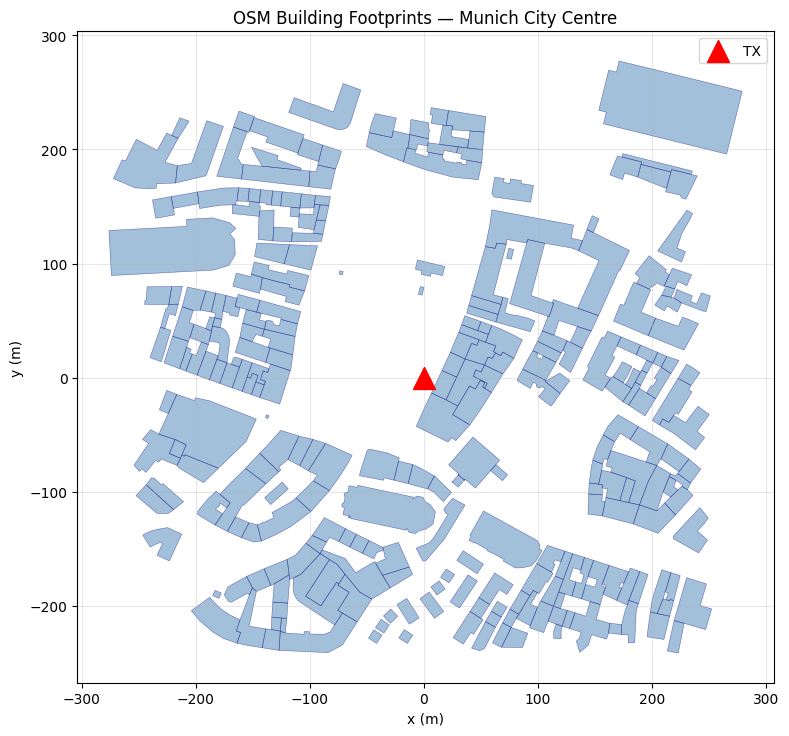

In [6]:
meshes_folder = Path(osm_scene_folder) / "meshes"

fig, ax = plt.subplots(figsize=(8, 8))
for ply_file in sorted(meshes_folder.glob("building_*.ply")):
    lines = ply_file.read_text(encoding="utf-8").splitlines()
    hdr_end = next(i for i, ln in enumerate(lines) if ln == "end_header")
    n_verts = int(next(ln.split()[-1] for ln in lines if "element vertex" in ln))
    # Bottom-ring vertices are the first half of the vertex list (z = 0)
    z_tol = 0.01  # ground-level tolerance in metres
    min_poly_pts = 3
    footprint = [
        tuple(map(float, lines[hdr_end + 1 + i].split()))
        for i in range(n_verts)
        if abs(float(lines[hdr_end + 1 + i].split()[2])) < z_tol
    ]
    if len(footprint) >= min_poly_pts:
        xs = [v[0] for v in footprint] + [footprint[0][0]]
        ys = [v[1] for v in footprint] + [footprint[0][1]]
        ax.fill(xs, ys, alpha=0.5, color="steelblue", edgecolor="navy", linewidth=0.4)

ax.scatter(*TX_POS[0, :2], c="red", marker="^", s=250, zorder=5, label="TX")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("OSM Building Footprints — Munich City Centre")
ax.set_aspect("equal")
ax.grid(visible=True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Step 2 — Load the Scene in Sionna RT

In [7]:
xml_path = str(Path(osm_scene_folder) / "scene.xml")
scene = sionna_rt.load_scene(xml_path, merge_shapes=False)
scene.frequency = CARRIER_FREQ

print(f"Scene loaded: {len(scene.objects)} objects")
print(f"Sample materials: {[o.radio_material.name for o in list(scene.objects.values())[:4]]}")

# Single isotropic antenna for both TX and RX
single_ant = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)
scene.tx_array = single_ant
scene.rx_array = single_ant

Scene loaded: 266 objects
Sample materials: ['concrete', 'concrete', 'concrete', 'concrete']


## Step 3 — Place Transmitter and Receivers

The base station is placed at the centre of the area at rooftop height.
UEs are placed on a regular grid at street level.

In [8]:
origin_lat, origin_lon = get_origin_coords(osm_scene_folder)
print(f"Local coordinate origin: ({origin_lat:.6f}, {origin_lon:.6f})")

xmin, ymin, xmax, ymax = convert_GpsBBox2CartesianBBox(
    BBOX["minlat"],
    BBOX["minlon"],
    BBOX["maxlat"],
    BBOX["maxlon"],
    origin_lat,
    origin_lon,
)
print(f"Scene extent: X=[{xmin:.0f}, {xmax:.0f}] m,  Y=[{ymin:.0f}, {ymax:.0f}] m")

# Add transmitter
scene.add(Transmitter("tx_0", position=TX_POS[0].tolist()))
print(f"TX at {TX_POS[0]}")

# Generate UE grid
rx_pos = gen_plane_grid(xmin + 10, xmax - 10, ymin + 10, ymax - 10, GRID_SPACING, UE_HEIGHT)
print(f"UE grid: {len(rx_pos)} positions")

for i, pos in enumerate(rx_pos):
    rx = Receiver(f"rx_{i}", position=pos.tolist())
    rx.display_radius = 5.0  # metres; default heuristic is too large for this scene
    scene.add(rx)
print(f"Added {len(rx_pos)} receivers")

Local coordinate origin: (48.137500, 11.576500)
Scene extent: X=[-216, 216] m,  Y=[-230, 230] m
TX at [ 0.  0. 25.]
UE grid: 240 positions
Added 240 receivers


## Visualize — Sionna RT Scene Render

Sionna renders the 3D scene using Mitsuba's physically-based renderer.
Buildings are visible as 3D blocks; the red marker is the TX and the blue
spheres are the UE grid.

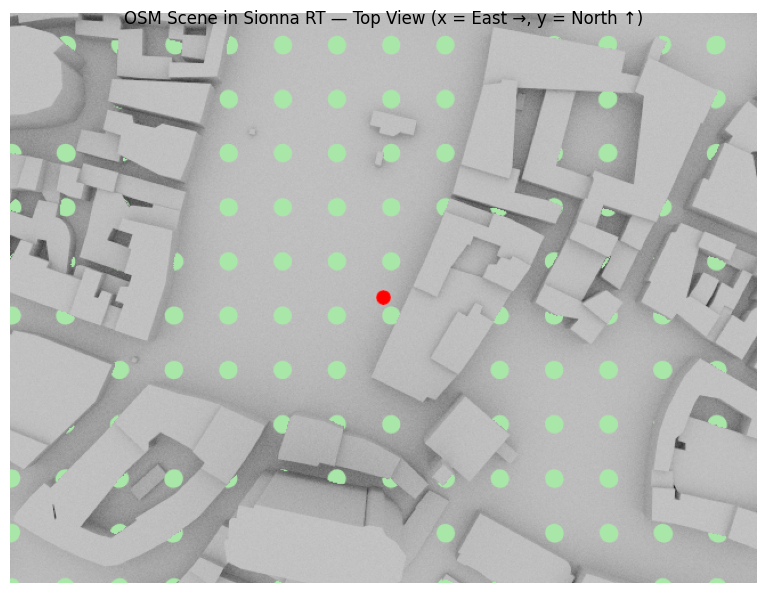

In [9]:
# Camera offset slightly south so Sionna's Z-up convention renders
# East (x+) right and North (y+) up — matching the 2D footprint above.
cam_top = Camera(position=[0.0, -5.0, 500.0], look_at=[0.0, 0.0, 0.0])
fig = scene.render(camera=cam_top, show_devices=True)
fig.suptitle("OSM Scene in Sionna RT — Top View (x = East →, y = North ↑)")
plt.show()

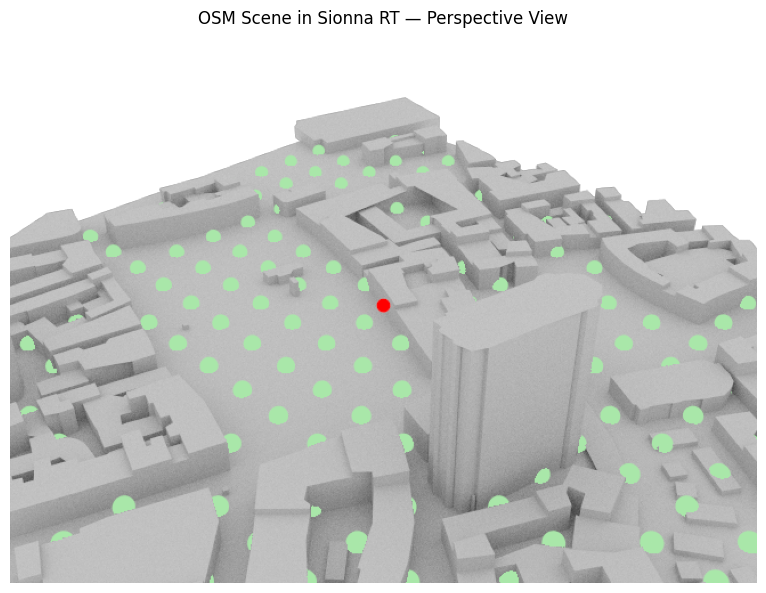

In [10]:
# South-facing oblique: consistent with top-down (East right, North into scene)
cam_oblique = Camera(position=[-300.0, -300.0, 300.0], look_at=[0.0, 0.0, 30.0])
fig = scene.render(camera=cam_oblique, show_devices=True)
fig.suptitle("OSM Scene in Sionna RT — Perspective View")
plt.show()

## Step 4 — Run Sionna RT Ray Tracing

In [11]:
RT_PARAMS = {
    "max_depth": MAX_DEPTH,
    "los": True,
    "specular_reflection": True,
    "diffuse_reflection": False,
    "refraction": False,
    "samples_per_src": N_SAMPLES,
}

print("Running ray tracing...")
p_solver = PathSolver()
paths = p_solver(scene=scene, **RT_PARAMS)

print(f"Path delays shape (tau): {paths.tau.shape}")
print("  (num_rx, num_tx, num_paths)")

Running ray tracing...


Path delays shape (tau): (240, 1, 19)
  (num_rx, num_tx, num_paths)


## Step 5 — Export with `sionna_exporter`

In [12]:
rt_save_folder = str(WORK_DIR / "sionna_rt_export")
sionna_exporter(scene, paths, RT_PARAMS, rt_save_folder)

print(f"\nExported files in {rt_save_folder}:")
for f in sorted(Path(rt_save_folder).iterdir()):
    print(f"  {f.name:<40}  {f.stat().st_size / 1024:7.1f} KB")


Exported files in /home/joao/.cache/deepmimo/osm_pipeline_munich/sionna_rt_export:
  sionna_faces.pkl                             72.7 KB
  sionna_material_indices.pkl                   2.2 KB
  sionna_materials.pkl                          0.4 KB
  sionna_objects.pkl                            5.8 KB
  sionna_paths.pkl                            270.6 KB
  sionna_rt_params.pkl                          0.6 KB
  sionna_vertices.pkl                          52.7 KB


## Step 6 — Convert to DeepMIMO Format

Determining converter...
Using Sionna RT converter
converting from sionna RT


Processing receivers for TX 0, Ant 0:   0%|          | 0/240 [00:00<?, ?it/s]

Processing receivers for TX 0, Ant 0: 100%|██████████| 240/240 [00:00<00:00, 22640.81it/s]

Converted scenario: sionna_rt_export


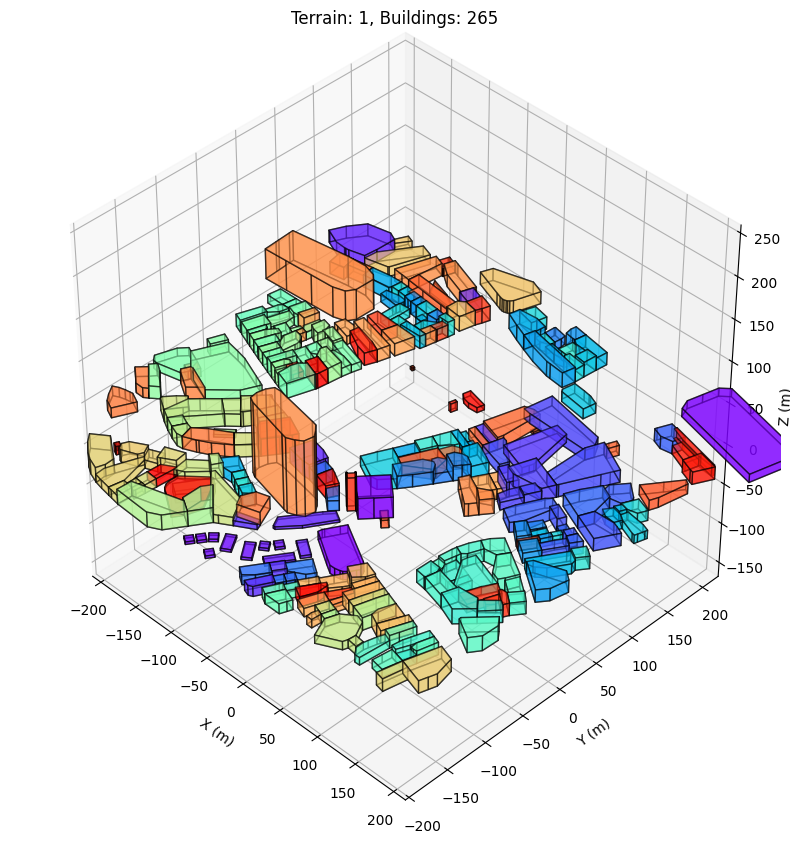

In [13]:
scenario_name = dm.convert(rt_save_folder, overwrite=True)
print(f"Converted scenario: {scenario_name}")

## Step 7 — Load and Inspect the DeepMIMO Dataset

In [14]:
dataset = dm.load(scenario_name)
print(dataset)

Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 240)
{'aoa_az': array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(240, 19), dtype=float32),
 'aoa_el': array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(240, 19), dtype=float32),
 'aod_az': array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan

## Step 8 — Received Power Coverage Map

Per-UE peak received power (across paths) plotted as a scatter map.
UEs with no paths (obstructed or out-of-range) are shown in grey.

/tmp/ipykernel_615567/2146066148.py:2: RuntimeWarning: All-NaN axis encountered
  power_peak = np.nanmax(dataset.power, axis=1)  # (n_ue,) in dBW


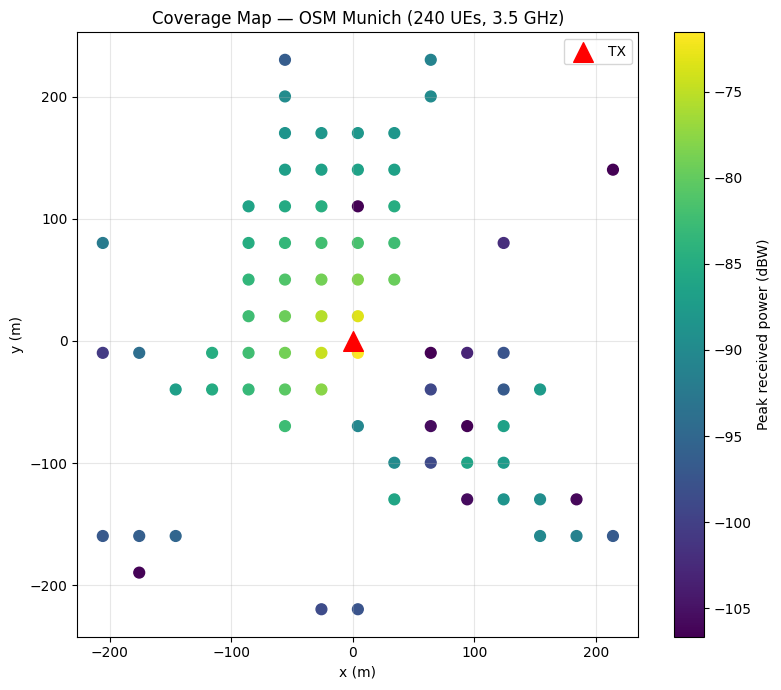

In [15]:
rx_pos_arr = np.array(dataset.rx_pos)
power_peak = np.nanmax(dataset.power, axis=1)  # (n_ue,) in dBW

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    rx_pos_arr[:, 0],
    rx_pos_arr[:, 1],
    c=power_peak,
    cmap="viridis",
    s=60,
    vmin=np.nanpercentile(power_peak, 5),
)
ax.scatter(*TX_POS[0, :2], c="red", marker="^", s=200, zorder=5, label="TX")
plt.colorbar(sc, ax=ax, label="Peak received power (dBW)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Coverage Map — OSM Munich ({len(rx_pos)} UEs, {CARRIER_FREQ / 1e9:.1f} GHz)")
ax.legend()
ax.grid(visible=True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Step | Tool | Output |
|------|------|--------|
| 1. OSM → scene | `generate_scene` | `scene.xml` + PLY meshes |
| 2. Load scene | `sionna.rt.load_scene` | Sionna `Scene` object |
| 3. Place antennas | `Transmitter` / `Receiver` | TX + UE grid |
| 4. Ray trace | `PathSolver` | `Paths` object |
| 5. Export | `sionna_exporter` | `.pkl` files |
| 6. Convert | `dm.convert` | DeepMIMO scenario |
| 7. Load | `dm.load` | `Dataset` object |
| 8. Coverage map | `dataset.power` | Per-UE received power scatter |

**Key design choices:**
- **No Blender** — `generate_scene` fetches OSM data via the Overpass API and
  writes Mitsuba PLY meshes directly in Python.
- **ITU radio materials** — buildings use `itu-radio-material type=concrete`,
  matching the material convention of Sionna's built-in scenes.
- **Local coordinate system** — the centre of the GPS bounding box is the
  origin; `osm_gps_origin.txt` records this for downstream use.
- **Reusable scene folder** — the generated `scene.xml` folder can be fed
  directly into `raytrace_sionna()` for large-scale batch processing.
- **Satellite overlay** — optionally add a Google Maps satellite image with
  `deepmimo.pipelines.utils.geo_utils.fetch_satellite_view(bbox, api_key, ...)`.